# Exercício de pandas e dataviz - Introdução à ciência de dados

Neste notebook, você vai praticar pandas e visualização de dados usando o conjunto de dados do Titanic.

A documentação oficial do pandas encontra-se em: https://pandas.pydata.org/docs/

A documentação oficial do matplotlib encontra-se em: https://matplotlib.org/stable/index.html

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Vamos analisar e trabalhar com um conjunto de dados incluído no Seaborn, com informações sobre os passageiros do Titanic.

**Execute a célula a seguir para carregá-lo automaticamente.**

In [4]:
titanic_df = sns.load_dataset("titanic")

In [5]:
display(titanic_df.head())
display(titanic_df.info())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


None

**1. Quantos passageiros existem no DataFrame?**

Dica: cada linha do dataframe diz respeito a um passageiro diferente.

In [8]:
len(titanic_df)

891

- Ha 891 passageiros no df

**2. Obtenha a lista de cidades de onde os passageiros embarcaram.**

*Dica: método `.unique()`*

In [10]:
titanic_df['embark_town'].unique()

<StringArray>
['Southampton', 'Cherbourg', 'Queenstown', nan]
Length: 4, dtype: str

- Os passageiros embarcaram em Southampton, Cherbourg e Queenstown

**3. Qual foi a receita total das passagens dos passageiros listados neste conjunto de dados?**

In [57]:
titanic_df['fare'].sum().round(2)

np.float64(28693.95)

- Foi de 28693,95 euros a receita total

**4. Crie um dataset com os 20 passageiros mais velhos.**

In [13]:
df_velhos = titanic_df.sort_values(by='age',ascending=False).head(20)
display(df_velhos)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
630,1,1,male,80.0,0,0,30.0000,S,First,man,True,A,Southampton,yes,True
851,0,3,male,74.0,0,0,7.7750,S,Third,man,True,NaN,Southampton,no,True
493,0,1,male,71.0,0,0,49.5042,C,First,man,True,NaN,Cherbourg,no,True
96,0,1,male,71.0,0,0,34.6542,C,First,man,True,A,Cherbourg,no,True
116,0,3,male,70.5,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True
745,0,1,male,70.0,1,1,71.0000,S,First,man,True,B,Southampton,no,False
672,0,2,male,70.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
33,0,2,male,66.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
456,0,1,male,65.0,0,0,26.5500,S,First,man,True,E,Southampton,no,True
54,0,1,male,65.0,0,1,61.9792,C,First,man,True,B,Cherbourg,no,False


**5. Adicione uma nova coluna `compensacao` em `titanic_df` para guardar a indenização paga aos sobreviventes, assumindo um valor de 900 vezes o valor da passagem paga pelo passageiro. A indenização deve ser 0 para quem não sobreviveu.**

*(Observação: na realidade, não foi paga nenhuma indenização aos sobreviventes.)*

In [16]:
titanic_df['compensacao'] = titanic_df['fare'] * 900 * titanic_df['survived']

titanic_df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,compensacao
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,0.00
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,64154.97
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,7132.50
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,47790.00
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0.00


**6. Crie um DataFrame que mostre a idade média por classe.**

*Dica: use o `groupby`.*

In [17]:
df_idade_media = titanic_df.groupby('class')['age'].mean()

df_idade_media.head()

class
First     38.233441
Second    29.877630
Third     25.140620
Name: age, dtype: float64

**7. Conte o número de passageiros cuja idade está em falta/nula.**


In [40]:
len(titanic_df) - titanic_df['age'].notnull().sum()

np.int64(177)

- 177 idades nao foram registradas

**ATENÇÃO: Execute as células de código a seguir antes de prosseguir para a resolução da questão 8**

Vamos considerar um DataFrame simples com os países onde o Titanic fez paradas.

In [21]:
cidades_parada = ['Cherbourg', 'Queenstown', 'Southampton']
paises = ['França', 'Irlanda', 'Reino Unido']
pnb_1925 = [36262, 1862, 43700]  
expectativa_vida_1926 = [54, 59.6, 54]

dados_paises = {
    'cidade': cidades_parada,
    'pais': paises,
    'pnb': pnb_1925,
    'expectativa_vida': expectativa_vida_1926
}

paises_df = pd.DataFrame(dados_paises)
paises_df

,cidade,pais,pnb,expectativa_vida
0,Cherbourg,França,36262,54.0
1,Queenstown,Irlanda,1862,59.6
2,Southampton,Reino Unido,43700,54.0


Vamos juntar os dois DataFrames para calcular mais algumas métricas.

In [22]:
dados_combinados_df = titanic_df.merge(
    paises_df,
    left_on="embark_town",
    right_on="cidade",
    how="outer"
)

dados_combinados_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,compensacao,cidade,pais,pnb,expectativa_vida
0,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,64154.97,Cherbourg,França,36262.0,54.0
1,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False,27063.72,Cherbourg,França,36262.0,54.0
2,1,3,female,NaN,0,0,7.2250,C,Third,woman,False,NaN,Cherbourg,yes,True,6502.50,Cherbourg,França,36262.0,54.0
3,0,3,male,NaN,0,0,7.2250,C,Third,man,True,NaN,Cherbourg,no,True,0.00,Cherbourg,França,36262.0,54.0
4,0,1,male,40.0,0,0,27.7208,C,First,man,True,NaN,Cherbourg,no,True,0.00,Cherbourg,França,36262.0,54.0


**8. Adicione uma coluna `percentual_vida` em `dados_combinados_df` com a porcentagem de vida vivida de cada passageiro, considerando sua idade e expectativa de vida.**

In [23]:
dados_combinados_df['percentual_vida'] = (dados_combinados_df['age'] / dados_combinados_df['expectativa_vida']) * 100

dados_combinados_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,deck,embark_town,alive,alone,compensacao,cidade,pais,pnb,expectativa_vida,percentual_vida
0,1,1,female,38.0,1,0,71.2833,C,First,woman,...,C,Cherbourg,yes,False,64154.97,Cherbourg,França,36262.0,54.0,70.370370
1,1,2,female,14.0,1,0,30.0708,C,Second,child,...,NaN,Cherbourg,yes,False,27063.72,Cherbourg,França,36262.0,54.0,25.925926
2,1,3,female,NaN,0,0,7.2250,C,Third,woman,...,NaN,Cherbourg,yes,True,6502.50,Cherbourg,França,36262.0,54.0,NaN
3,0,3,male,NaN,0,0,7.2250,C,Third,man,...,NaN,Cherbourg,no,True,0.00,Cherbourg,França,36262.0,54.0,NaN
4,0,1,male,40.0,0,0,27.7208,C,First,man,...,NaN,Cherbourg,no,True,0.00,Cherbourg,França,36262.0,54.0,74.074074


**9. Crie um histograma que permita visualizar de forma agregada a idade dos passageiros, em 8 grupos. Dê ao gráfico o título "Distribuição das idades dos passageiros".**

Text(0.5, 0, 'Idade')

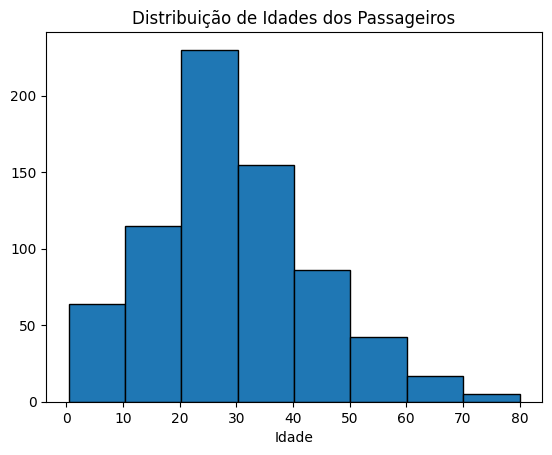

In [55]:
plt.hist(dados_combinados_df['age'].dropna(), bins=8, edgecolor='black')
plt.title('Distribuição de Idades dos Passageiros')
plt.xlabel('Idade')

**10. Crie um gráfico de barras com o número de sobreviventes, colocando o sexo no eixo x.**

Text(0.5, 0, 'Gênero')

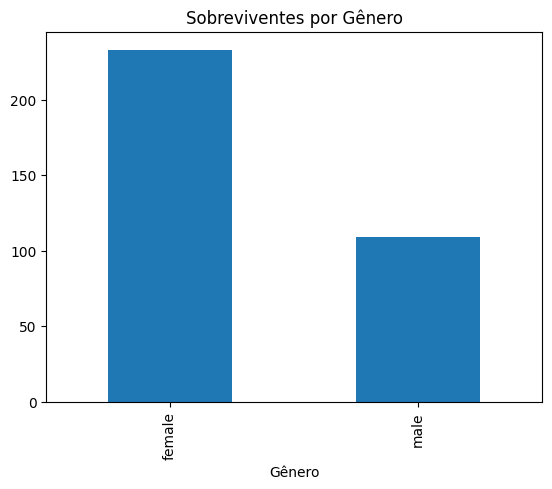

In [54]:
dados_combinados_df['sex'][dados_combinados_df['survived'] == 1].value_counts().plot(kind='bar')
plt.title('Sobreviventes por Gênero')
plt.xlabel('Gênero')

**11. Crie um gráfico de barras com o número de passageiros por cidade de embarque.**

Text(0.5, 0, 'Cidade de Embarque')

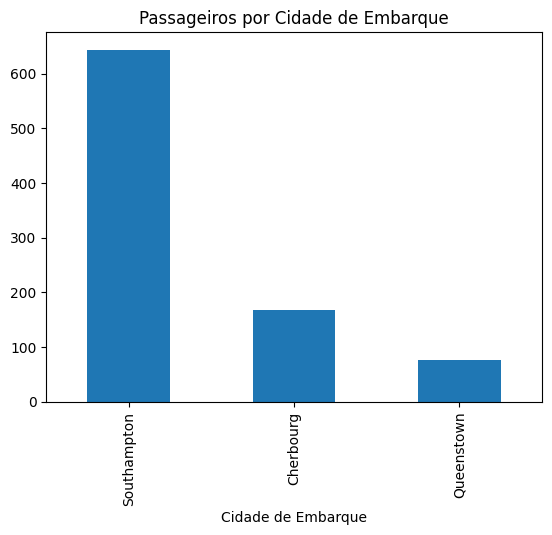

In [51]:
dados_combinados_df['embark_town'].dropna().value_counts().plot(kind='bar')
plt.title('Passageiros por Cidade de Embarque')
plt.xlabel('Cidade de Embarque')

**12. Crie um boxplot para verificar a distribuição da variável `fare`.**

Text(0.5, 0, 'Passageiros')

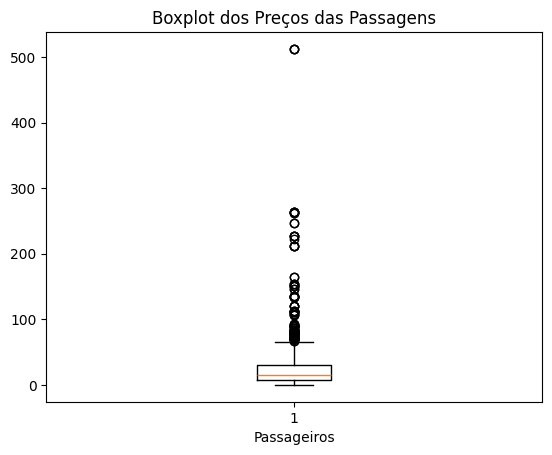

In [52]:
plt.boxplot(dados_combinados_df['fare'])
plt.title('Boxplot dos Preços das Passagens')
plt.xlabel('Passageiros')